In [ ]:
!pip install torch transformers pandas
!pip install Keras-Preprocessing
!pip install datasets
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 16.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix
import os
os.environ["OMP_NUM_THREADS"] = "1" # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "1" # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "1" # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" # export VECLIB_MAXIMUM_THREADS=1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size') > 200]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2121 entries, 524 to 61818
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2121 non-null   object 
 1   country                             2121 non-null   object 
 2   contest_url                         2121 non-null   object 
 3   num_of_contest                      2121 non-null   int64  
 4   is_weekly                           2121 non-null   bool   
 5   rank                                2121 non-null   int64  
 6   score                               2121 non-null   int64  
 7   question_number                     2121 non-null   int64  
 8   question_language                   2121 non-null   object 
 9   question_code                       2121 non-null   object 
 10  number_of_lines                     2121 non-null   int64  
 11  names_set                           2121 non-

In [ ]:
leetcode_questions_df.country.value_counts()

,count
country,
India,1412
United States,709


In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,...,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,297.401226,652.641207,15.714757,3.390382,78.917963,47.370108,25.723244,4.245639,4.736917,6.799151,...,0.052939,0.085279,0.113619,0.102596,3588.046676,2670.565771,1279.405941,0.020484,2271.371523,7.768505
std,120.347303,339.661963,2.920845,0.487951,273.654089,64.074384,37.173818,20.640373,13.691293,22.734672,...,0.039439,0.063524,0.074629,0.177937,1549.854140,1310.367498,920.812675,0.055288,7885.149972,6.664371
min,116.000000,2.000000,8.000000,3.000000,6.000000,12.000000,4.000000,1.000000,0.000000,0.000000,...,0.006993,0.000000,0.000000,0.000000,371.000000,164.000000,0.000000,0.000001,144.000000,1.000000
25%,125.000000,375.000000,12.000000,3.000000,31.000000,30.000000,16.000000,1.000000,1.000000,2.000000,...,0.030303,0.040000,0.064516,0.000000,2309.000000,1565.000000,606.000000,0.000525,914.000000,2.000000
50%,374.000000,668.000000,17.000000,3.000000,45.000000,38.000000,21.000000,2.000000,3.000000,4.000000,...,0.044118,0.076923,0.102564,0.000000,3599.000000,2491.000000,1083.000000,0.002613,1319.000000,5.000000
75%,384.000000,941.000000,18.000000,4.000000,64.000000,47.000000,26.000000,3.000000,5.000000,6.000000,...,0.063830,0.111111,0.150000,0.166667,4872.000000,3643.000000,1723.000000,0.011785,1852.000000,12.000000
max,390.000000,1225.000000,20.000000,4.000000,2861.000000,661.000000,389.000000,213.000000,146.000000,250.000000,...,0.433333,0.521739,0.645833,0.902439,11651.000000,5399.000000,5219.000000,0.828094,82658.000000,29.000000


In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
import re

def remove_class_definition(java_code):
    # Regular expression to match the class definition
    # This regex will match 'class Solution {' and capture everything inside until the last closing brace '}'
    class_pattern = r'class\s+Solution\s*{(.*?)}\s*$'

    # Use re.DOTALL to allow '.' to match newlines as well
    match = re.search(class_pattern, java_code, re.DOTALL)

    if match:
        # Get the contents inside the class
        inside_class = match.group(1)

        # Strip leading and trailing whitespaces or newlines
        stripped_code = inside_class.strip()

        return stripped_code
    else:
        # If pattern does not match, return original code
        return java_code

X.question_code = X.question_code.apply(remove_class_definition)

In [ ]:
X.question_number = X.question_number.astype("category")

In [ ]:
X_nontext=X[['question_number', 'question_finish_time_total_seconds', 'number_of_lines',
            'token_count', 'variables_count', 'function_count', 'loop_count',
            'condition_count', 'single_line_comment_density',
            'multiline_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]

one_hot = pd.get_dummies(X_nontext.question_number, prefix='question_number', drop_first=True)
X_nontext = X_nontext.drop('question_number', axis=1)
X_nontext = pd.concat([X_nontext, one_hot], axis=1)

X_nontext.question_finish_time_total_seconds = X_nontext.question_finish_time_total_seconds.astype(int)

X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2121 entries, 524 to 61818
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   question_finish_time_total_seconds  2121 non-null   int64  
 1   number_of_lines                     2121 non-null   int64  
 2   token_count                         2121 non-null   int64  
 3   variables_count                     2121 non-null   int64  
 4   function_count                      2121 non-null   int64  
 5   loop_count                          2121 non-null   int64  
 6   condition_count                     2121 non-null   int64  
 7   single_line_comment_density         2121 non-null   float64
 8   multiline_comment_density           2121 non-null   float64
 9   function_density                    2121 non-null   float64
 10  loop_density                        2121 non-null   float64
 11  condition_density                   2121 non-

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)
X_train_nontext, X_test_nontext, _, _ = train_test_split(X_nontext, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)
X_train_nontext, X_valid_nontext, _, _ = train_test_split(X_train_nontext, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [ ]:
num_labels = len(enc.classes_)
num_labels

2

## CatBoostClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC(random_state=42))])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6927222677222676


In [ ]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_weighted')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_cat_train_pred = best_svc.predict(X_train_nontext)
y_cat_test_pred = best_svc.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_cat_test_pred, average = 'weighted'))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters found:  {'classifier__C': 100, 'classifier__gamma': 'scale'}
Best F1 score found:  0.6410852302819567
Test set F1 score:  0.6642556739231125


               precision    recall  f1-score   support

        India       0.72      0.89      0.80       283
United States       0.59      0.30      0.40       142

     accuracy                           0.70       425
    macro avg       0.65      0.60      0.60       425
 weighted avg       0.68      0.70      0.66       425

f1_score :  0.6642556739231125


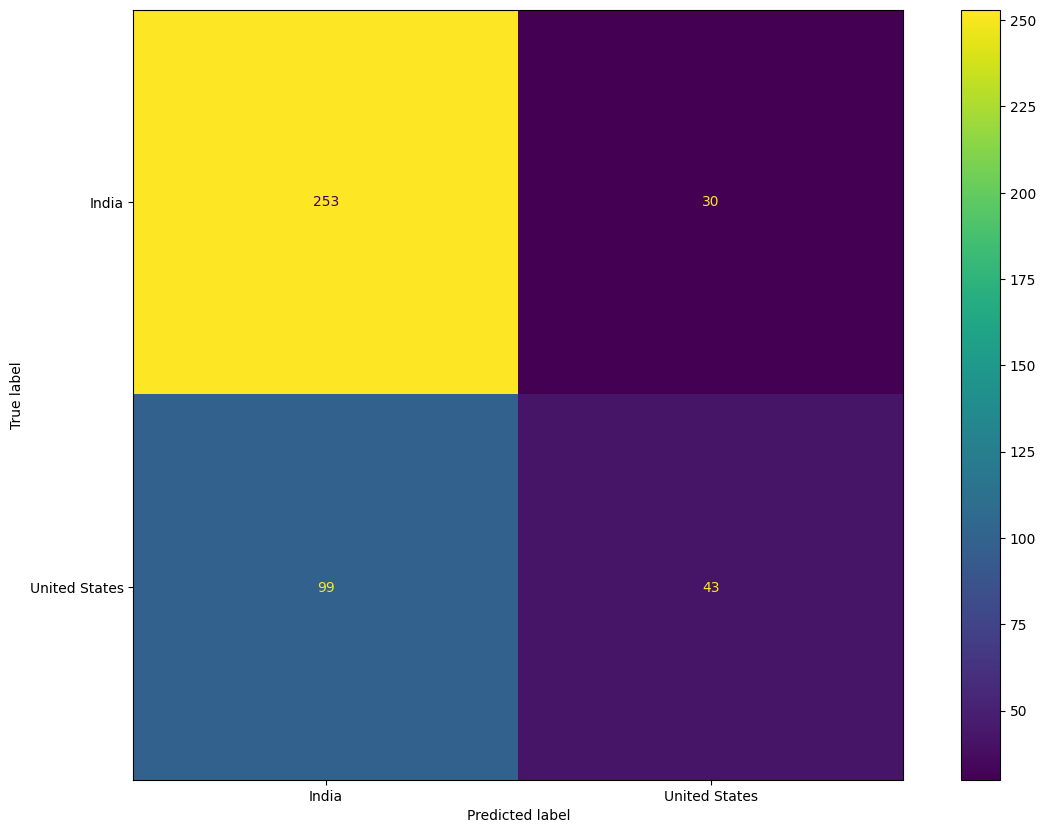

In [ ]:
print(classification_report(y_test, y_cat_test_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_test, y_cat_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_cat_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

## CodeBert

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-java"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at neulab/codebert-java and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text.reset_index(drop=True), y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text.reset_index(drop=True), y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text.reset_index(drop=True), y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Step 1: Calculate class weights based on your dataset
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 2: Define a custom Trainer to incorporate class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Define the weighted loss
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=40,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.05,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=1e-5,
    save_total_limit=2,
    metric_for_best_model='f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [ ]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    f1 = f1_score(p.label_ids, preds, average='macro')  # Use macro average for multiclass classification
    return {"f1": f1}

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.717700,0.697067,0.502310
2,0.683600,0.654957,0.671996
3,0.592100,0.568977,0.687256
4,0.584200,0.543992,0.678345
5,0.484700,0.485880,0.750259
6,0.492400,0.451029,0.825425
7,0.315700,0.404725,0.821230
8,0.258500,0.421398,0.834103
9,0.260200,0.395631,0.857552
10,0.210300,0.405515,0.865888


TrainOutput(global_step=1860, training_loss=0.26210215460604197, metrics={'train_runtime': 1748.0666, 'train_samples_per_second': 33.958, 'train_steps_per_second': 2.128, 'total_flos': 7809136123084800.0, 'train_loss': 0.26210215460604197, 'epoch': 20.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

               precision    recall  f1-score   support

        India       0.88      0.87      0.87       283
United States       0.75      0.75      0.75       142

     accuracy                           0.83       425
    macro avg       0.81      0.81      0.81       425
 weighted avg       0.83      0.83      0.83       425

f1_score :  0.8126067380841484


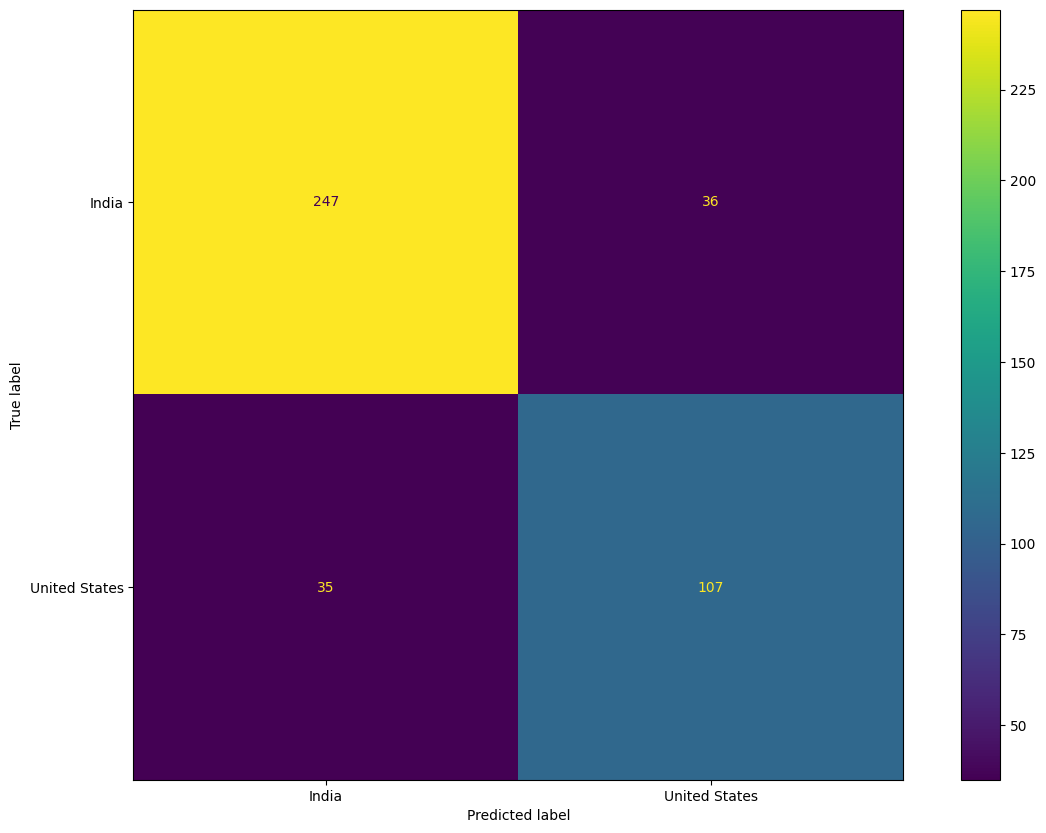

In [ ]:
print(classification_report(y_true, y_codebert_test_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_true, y_codebert_test_pred, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

               precision    recall  f1-score   support

        India       0.99      0.95      0.97       988
United States       0.91      0.99      0.95       496

     accuracy                           0.96      1484
    macro avg       0.95      0.97      0.96      1484
 weighted avg       0.97      0.96      0.96      1484

f1_score :  0.9592033608993055


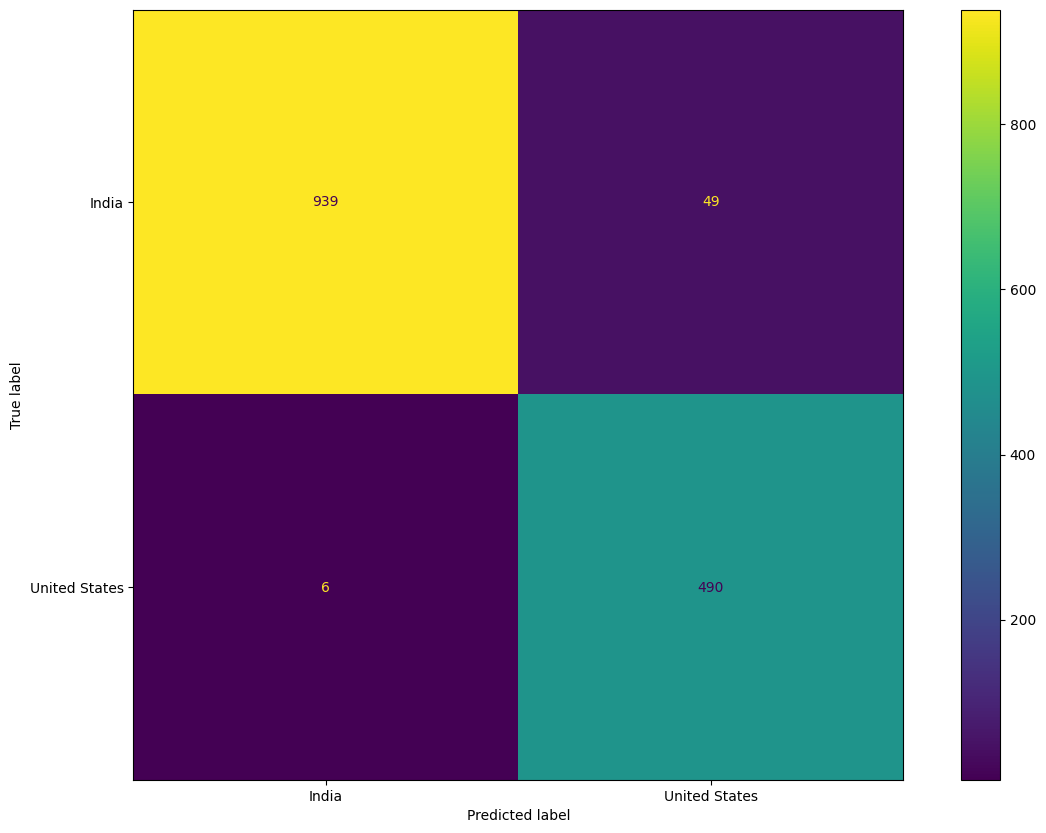

In [ ]:
print(classification_report(y_true, y_codebert_train_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_true, y_codebert_train_pred, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# Ensemble

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_X = np.column_stack((y_cat_train_pred.reshape(-1), y_codebert_train_pred))
meta_model = LogisticRegression()
meta_model.fit(meta_X, y_train)

# Final prediction
final_preds = meta_model.predict(np.column_stack((y_cat_test_pred.reshape(-1), y_codebert_test_pred)))

               precision    recall  f1-score   support

        India       0.72      0.89      0.80       283
United States       0.59      0.30      0.40       142

     accuracy                           0.70       425
    macro avg       0.65      0.60      0.60       425
 weighted avg       0.68      0.70      0.66       425

f1_score :  0.5984251968503937


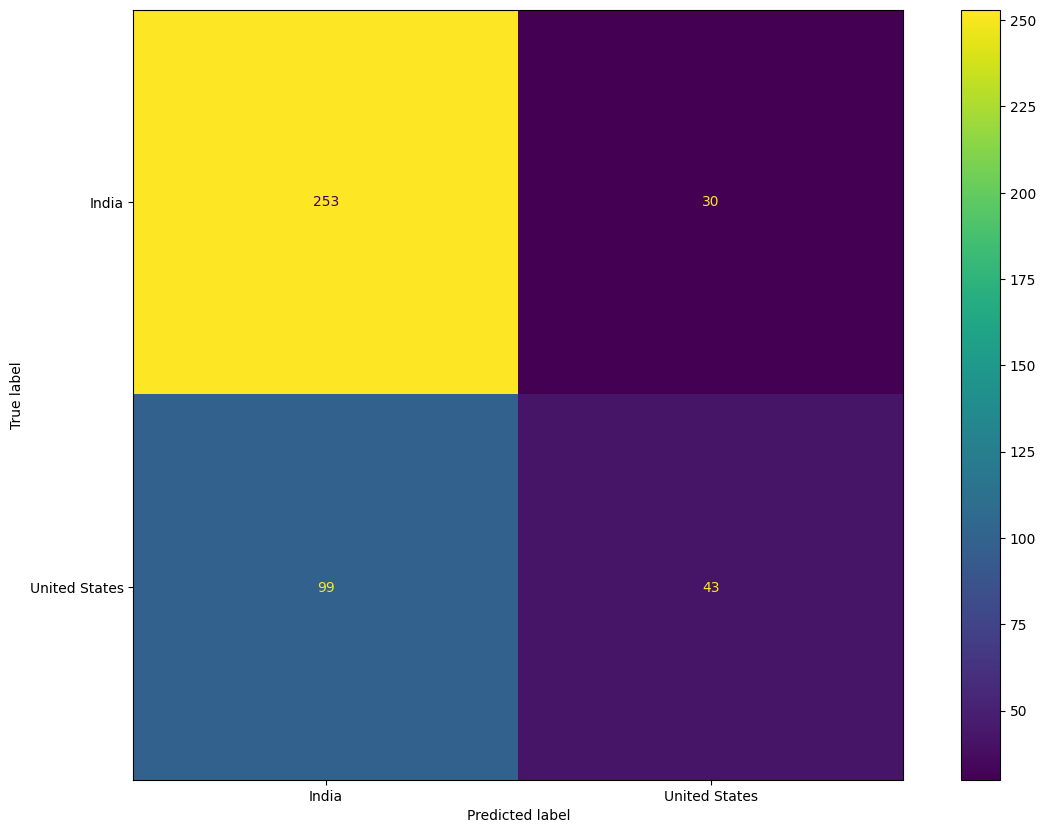

In [ ]:
print(classification_report(y_test, final_preds, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_test, final_preds, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, final_preds), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()